# MCAP-Housing Dataset Viewer

**模态**: RGB + Depth + IMU + PointCloud + Pose (egocentric manipulation)

- 2 段家务操作录像 (.mcap / ROS2 格式)
- 同步 RGB (1920x1440@60fps) + 16-bit Depth + 6-axis IMU + PointCloud + 6DoF Pose
- 每段 ~15,000 帧, ~30 GB
- 用于机器人操作学习、传感器融合、具身 AI

需要: `pip install mcap mcap-ros2-support`

In [1]:
import os
import struct

BASE = os.path.abspath(os.path.join(os.getcwd(), '..', 'dataset', 'MCAP-Housing'))

files = [f for f in os.listdir(BASE) if f.endswith('.mcap')]
for f in sorted(files):
    size_gb = os.path.getsize(os.path.join(BASE, f)) / 1e9
    print(f'{f:50s} {size_gb:.2f} GB')

print(f'\nTotal: {sum(os.path.getsize(os.path.join(BASE, f)) for f in files)/1e9:.1f} GB')

Transferring processed spices.mcap                 2.35 GB
Working mortar and Pestle.mcap                     6.71 GB

Total: 9.1 GB


## 1. MCAP File Structure Overview

In [2]:
try:
    from mcap.reader import make_reader
    HAS_MCAP = True
except ImportError:
    HAS_MCAP = False
    print('pip install mcap mcap-ros2-support')

if HAS_MCAP:
    mcap_file = os.path.join(BASE, sorted(files)[0])
    print(f'Reading: {os.path.basename(mcap_file)}')

    with open(mcap_file, 'rb') as f:
        reader = make_reader(f)
        summary = reader.get_summary()
        if summary:
            stats = summary.statistics
            duration_s = (stats.message_end_time - stats.message_start_time) / 1e9
            print(f'\nMessages: {stats.message_count:,}')
            print(f'Schemas:  {stats.schema_count}')
            print(f'Channels: {stats.channel_count}')
            print(f'Duration: {duration_s:.1f}s')
            print(f'\nChannels:')
            for ch_id, ch in summary.channels.items():
                msg_count = stats.channel_message_counts.get(ch_id, 0)
                print(f'  {ch.topic:45s} {msg_count:>8d} msgs')

Reading: Transferring processed spices.mcap

Messages: 25,972
Schemas:  11
Channels: 11
Duration: 39.7s

Channels:
  /camera/rgb/compressed                            2368 msgs
  /camera/depth/aligned                             2368 msgs
  /camera/depth/filtered                            2368 msgs
  /camera/depth/colorized                           2368 msgs
  /camera/points                                    2368 msgs
  /imu                                              2349 msgs
  /imu/gravity                                      2349 msgs
  /imu/orientation                                  2349 msgs
  /imu/mag                                          2349 msgs
  /camera/camera_info                               2368 msgs
  /tf                                               2368 msgs


## 2. Extract & Preview RGB Frames

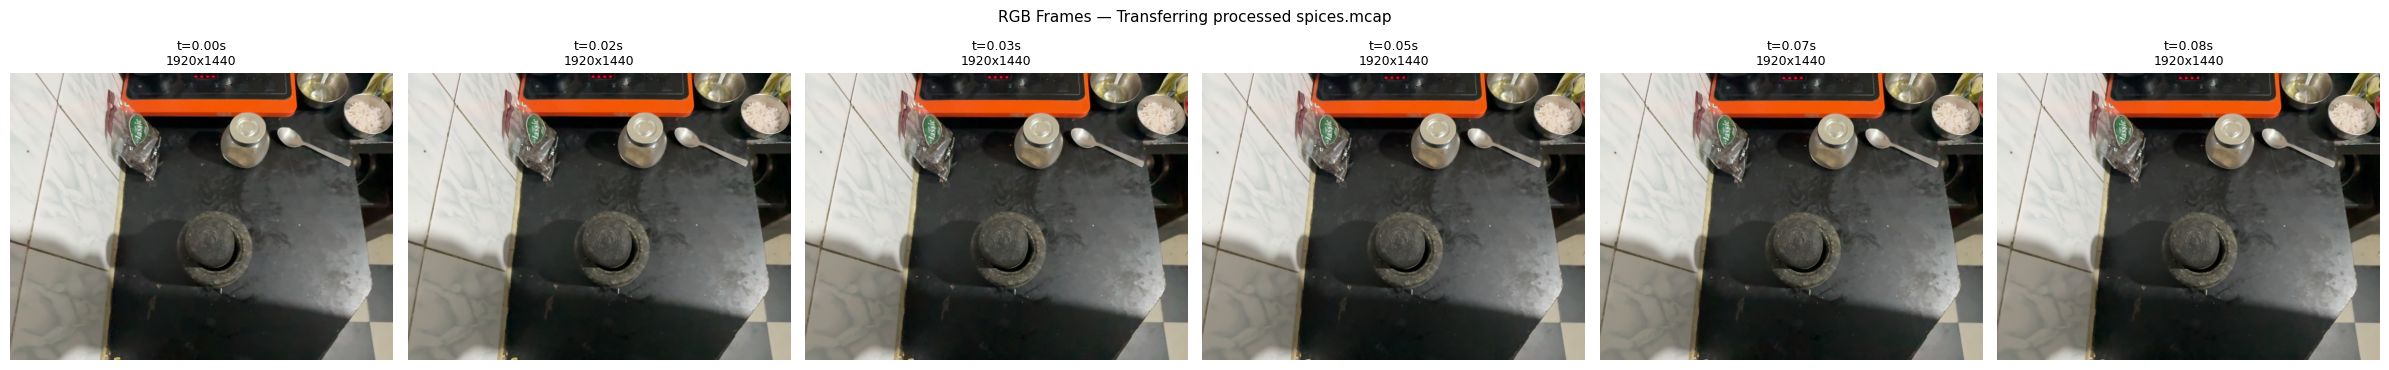

In [3]:
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

N_FRAMES = 6

if HAS_MCAP:
    try:
        from mcap_ros2.decoder import DecoderFactory
        HAS_ROS2 = True
    except ImportError:
        HAS_ROS2 = False
        print('pip install mcap-ros2-support for ROS2 message decoding')

    if HAS_ROS2:
        mcap_file = os.path.join(BASE, sorted(files)[0])
        rgb_frames = []
        timestamps = []

        with open(mcap_file, 'rb') as f:
            reader = make_reader(f, decoder_factories=[DecoderFactory()])
            for schema, channel, message, decoded in reader.iter_decoded_messages():
                if channel.topic == '/camera/rgb/compressed':
                    img_data = decoded.data
                    img = Image.open(io.BytesIO(img_data))
                    rgb_frames.append((message.log_time, img))
                    if len(rgb_frames) >= N_FRAMES:
                        break

        if rgb_frames:
            fig, axes = plt.subplots(1, len(rgb_frames), figsize=(4*len(rgb_frames), 4))
            if len(rgb_frames) == 1:
                axes = [axes]
            for ax, (ts, img) in zip(axes, rgb_frames):
                ax.imshow(img)
                ax.set_title(f't={ts/1e9:.2f}s\n{img.size[0]}x{img.size[1]}', fontsize=9)
                ax.axis('off')
            plt.suptitle(f'RGB Frames — {os.path.basename(mcap_file)}', fontsize=11)
            plt.tight_layout()
            plt.show()
        else:
            print('No RGB frames found in MCAP file')
else:
    print('Install mcap package to read MCAP files')

## 3. Extract & Preview Depth Frames

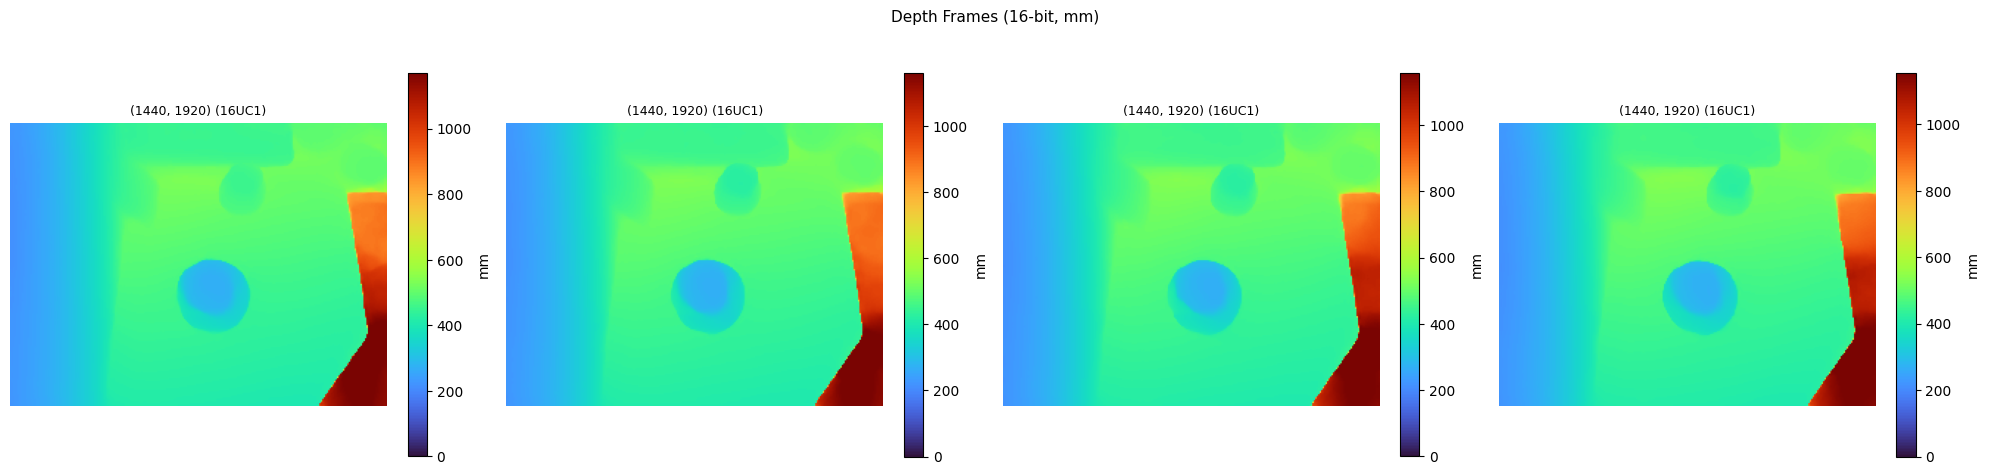

In [4]:
N_FRAMES = 4

if HAS_MCAP and HAS_ROS2:
    mcap_file = os.path.join(BASE, sorted(files)[0])
    depth_frames = []

    with open(mcap_file, 'rb') as f:
        reader = make_reader(f, decoder_factories=[DecoderFactory()])
        for schema, channel, message, decoded in reader.iter_decoded_messages():
            if channel.topic == '/camera/depth/aligned' and len(depth_frames) < N_FRAMES:
                w, h = decoded.width, decoded.height
                encoding = decoded.encoding
                raw = bytes(decoded.data)
                if encoding == '16UC1' or '16' in encoding:
                    arr = np.frombuffer(raw, dtype=np.uint16).reshape(h, w)
                else:
                    arr = np.frombuffer(raw, dtype=np.float32).reshape(h, w)
                depth_frames.append((message.log_time, arr, encoding))

    if depth_frames:
        fig, axes = plt.subplots(1, len(depth_frames), figsize=(5*len(depth_frames), 5))
        if len(depth_frames) == 1:
            axes = [axes]
        for ax, (ts, arr, enc) in zip(axes, depth_frames):
            valid = arr[arr > 0]
            vmax = np.percentile(valid, 98) if len(valid) > 0 else 1000
            im = ax.imshow(arr, cmap='turbo', vmin=0, vmax=vmax)
            plt.colorbar(im, ax=ax, fraction=0.046, label='mm')
            ax.set_title(f'{arr.shape} ({enc})', fontsize=9)
            ax.axis('off')
        plt.suptitle('Depth Frames (16-bit, mm)', fontsize=11)
        plt.tight_layout()
        plt.show()
    else:
        print('No depth frames found')
else:
    if not HAS_MCAP:
        print('Install mcap + mcap-ros2-support')

## 4. IMU Data Preview

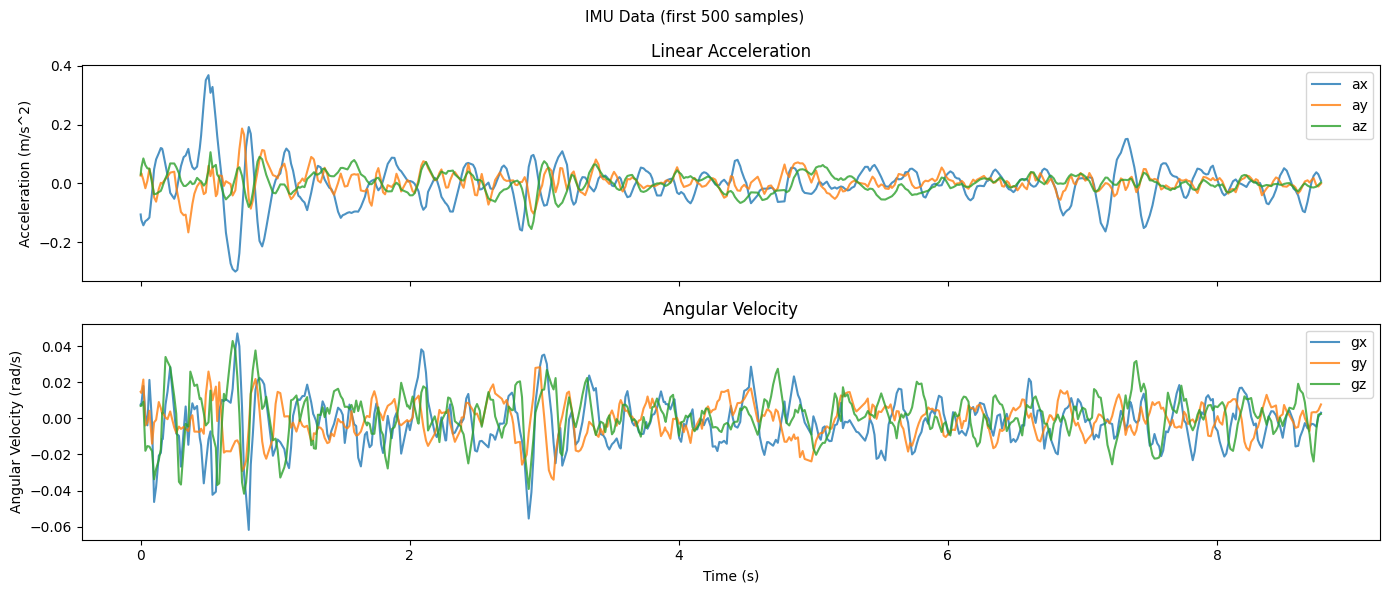

In [5]:
N_IMU = 500

if HAS_MCAP and HAS_ROS2:
    mcap_file = os.path.join(BASE, sorted(files)[0])
    imu_data = {'t': [], 'ax': [], 'ay': [], 'az': [], 'gx': [], 'gy': [], 'gz': []}

    with open(mcap_file, 'rb') as f:
        reader = make_reader(f, decoder_factories=[DecoderFactory()])
        for schema, channel, message, decoded in reader.iter_decoded_messages():
            if channel.topic == '/imu' and len(imu_data['t']) < N_IMU:
                imu_data['t'].append(message.log_time)
                imu_data['ax'].append(decoded.linear_acceleration.x)
                imu_data['ay'].append(decoded.linear_acceleration.y)
                imu_data['az'].append(decoded.linear_acceleration.z)
                imu_data['gx'].append(decoded.angular_velocity.x)
                imu_data['gy'].append(decoded.angular_velocity.y)
                imu_data['gz'].append(decoded.angular_velocity.z)

    if imu_data['t']:
        t_ns = np.array(imu_data['t'])
        t_s = (t_ns - t_ns[0]) / 1e9

        fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        axes[0].plot(t_s, imu_data['ax'], label='ax', alpha=0.8)
        axes[0].plot(t_s, imu_data['ay'], label='ay', alpha=0.8)
        axes[0].plot(t_s, imu_data['az'], label='az', alpha=0.8)
        axes[0].set_ylabel('Acceleration (m/s^2)')
        axes[0].set_title('Linear Acceleration')
        axes[0].legend(loc='upper right')

        axes[1].plot(t_s, imu_data['gx'], label='gx', alpha=0.8)
        axes[1].plot(t_s, imu_data['gy'], label='gy', alpha=0.8)
        axes[1].plot(t_s, imu_data['gz'], label='gz', alpha=0.8)
        axes[1].set_ylabel('Angular Velocity (rad/s)')
        axes[1].set_xlabel('Time (s)')
        axes[1].set_title('Angular Velocity')
        axes[1].legend(loc='upper right')

        plt.suptitle(f'IMU Data (first {len(imu_data["t"])} samples)', fontsize=11)
        plt.tight_layout()
        plt.show()
    else:
        print('No IMU data found')

## 5. Camera Trajectory (6DoF Pose)

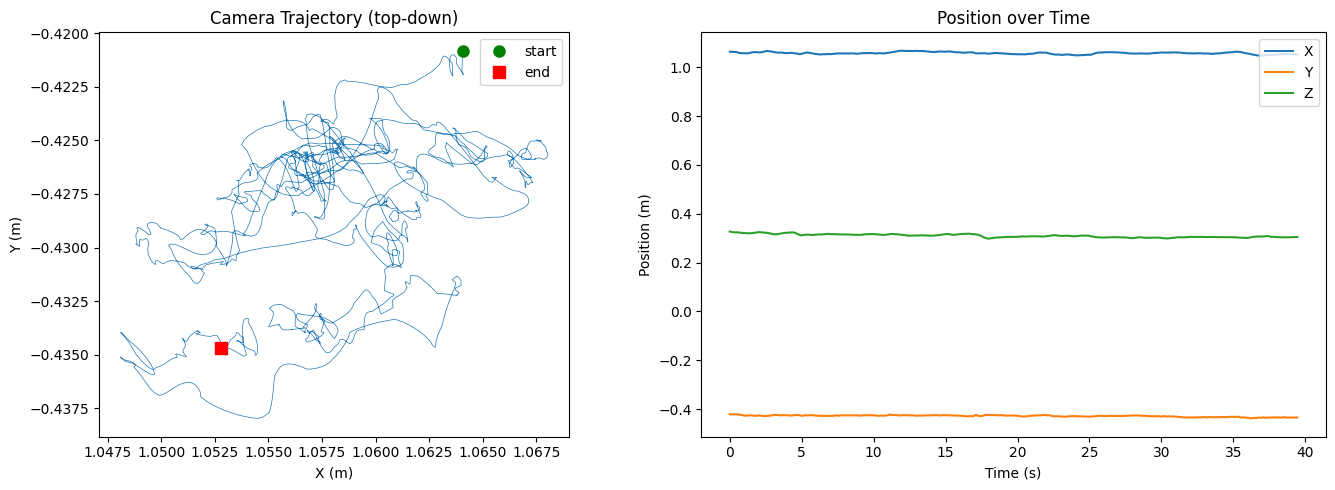

Total pose samples: 2368
Duration: 39.5s


In [6]:
if HAS_MCAP and HAS_ROS2:
    mcap_file = os.path.join(BASE, sorted(files)[0])
    poses_t = []
    poses_x = []
    poses_y = []
    poses_z = []

    with open(mcap_file, 'rb') as f:
        reader = make_reader(f, decoder_factories=[DecoderFactory()])
        for schema, channel, message, decoded in reader.iter_decoded_messages():
            if channel.topic == '/tf' and hasattr(decoded, 'transforms'):
                for t in decoded.transforms:
                    poses_t.append(message.log_time)
                    poses_x.append(t.transform.translation.x)
                    poses_y.append(t.transform.translation.y)
                    poses_z.append(t.transform.translation.z)

    if poses_t:
        poses_t = np.array(poses_t)
        t_s = (poses_t - poses_t[0]) / 1e9

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].plot(np.array(poses_x), np.array(poses_y), '-', linewidth=0.5)
        axes[0].set_xlabel('X (m)')
        axes[0].set_ylabel('Y (m)')
        axes[0].set_title('Camera Trajectory (top-down)')
        axes[0].set_aspect('equal')
        axes[0].plot(poses_x[0], poses_y[0], 'go', markersize=8, label='start')
        axes[0].plot(poses_x[-1], poses_y[-1], 'rs', markersize=8, label='end')
        axes[0].legend()

        axes[1].plot(t_s, poses_x, label='X')
        axes[1].plot(t_s, poses_y, label='Y')
        axes[1].plot(t_s, poses_z, label='Z')
        axes[1].set_xlabel('Time (s)')
        axes[1].set_ylabel('Position (m)')
        axes[1].set_title('Position over Time')
        axes[1].legend()
        plt.tight_layout()
        plt.show()
        print(f'Total pose samples: {len(poses_t)}')
        print(f'Duration: {t_s[-1]:.1f}s')
    else:
        print('No pose data found')

## 6. RGB-D Alignment Check

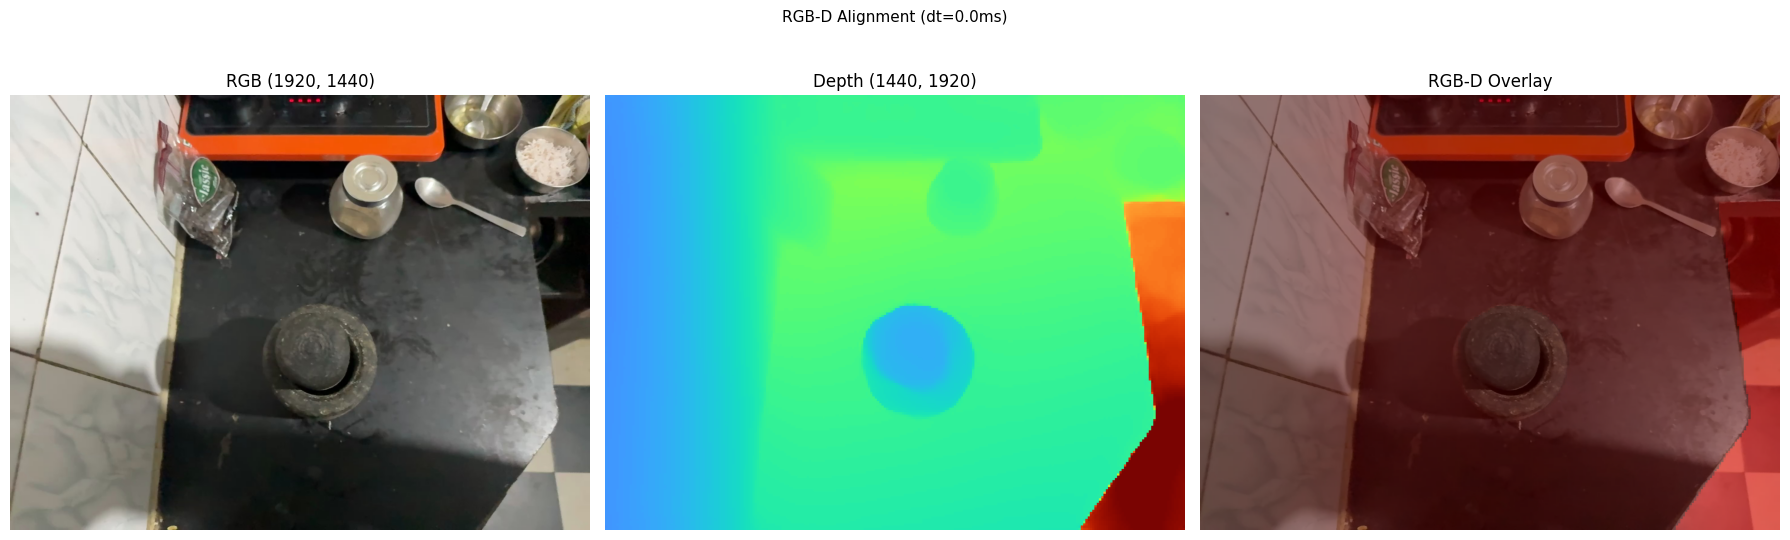

In [7]:
if HAS_MCAP and HAS_ROS2:
    mcap_file = os.path.join(BASE, sorted(files)[0])
    rgb_data = None
    depth_data = None

    with open(mcap_file, 'rb') as f:
        reader = make_reader(f, decoder_factories=[DecoderFactory()])
        for schema, channel, message, decoded in reader.iter_decoded_messages():
            if channel.topic == '/camera/rgb/compressed' and rgb_data is None:
                rgb_data = (message.log_time, decoded.data)
            if channel.topic == '/camera/depth/aligned' and depth_data is None:
                w, h = decoded.width, decoded.height
                raw = bytes(decoded.data)
                arr = np.frombuffer(raw, dtype=np.uint16).reshape(h, w)
                depth_data = (message.log_time, arr)
            if rgb_data and depth_data:
                break

    if rgb_data and depth_data:
        rgb_img = Image.open(io.BytesIO(rgb_data[1]))
        depth_arr = depth_data[1]
        dt = abs(rgb_data[0] - depth_data[0]) / 1e9

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(rgb_img)
        axes[0].set_title(f'RGB {rgb_img.size}')
        axes[0].axis('off')

        valid = depth_arr[depth_arr > 0]
        vmax = np.percentile(valid, 98) if len(valid) > 0 else 1000
        axes[1].imshow(depth_arr, cmap='turbo', vmin=0, vmax=vmax)
        axes[1].set_title(f'Depth {depth_arr.shape}')
        axes[1].axis('off')

        depth_vis = np.zeros((*depth_arr.shape, 3), dtype=np.uint8)
        depth_norm = np.clip(depth_arr / max(vmax, 1), 0, 1)
        depth_vis[:,:,0] = (depth_norm * 255).astype(np.uint8)
        rgb_resized = rgb_img.resize((depth_arr.shape[1], depth_arr.shape[0]), Image.BILINEAR)
        blend = np.array(rgb_resized).astype(float) * 0.5 + depth_vis.astype(float) * 0.5
        axes[2].imshow(blend.astype(np.uint8))
        axes[2].set_title('RGB-D Overlay')
        axes[2].axis('off')

        plt.suptitle(f'RGB-D Alignment (dt={dt*1000:.1f}ms)', fontsize=11)
        plt.tight_layout()
        plt.show()

## 7. Message Frequency Analysis

In [8]:
if HAS_MCAP and HAS_ROS2:
    from collections import defaultdict
    mcap_file = os.path.join(BASE, sorted(files)[0])
    topic_timestamps = defaultdict(list)

    with open(mcap_file, 'rb') as f:
        reader = make_reader(f, decoder_factories=[DecoderFactory()])
        for schema, channel, message, decoded in reader.iter_decoded_messages():
            topic_timestamps[channel.topic].append(message.log_time)

    print('Topic frequencies:')
    print(f'{"Topic":50s} {"Messages":>10s} {"Duration":>10s} {"Avg Hz":>10s}')
    print('-' * 82)
    for topic in sorted(topic_timestamps):
        ts = np.array(topic_timestamps[topic])
        dur = (ts[-1] - ts[0]) / 1e9
        hz = len(ts) / dur if dur > 0 else 0
        print(f'{topic:50s} {len(ts):10d} {dur:10.1f}s {hz:10.1f} Hz')

Topic frequencies:
Topic                                                Messages   Duration     Avg Hz
----------------------------------------------------------------------------------
/camera/camera_info                                      2368       39.5s       60.0 Hz
/camera/depth/aligned                                    2368       39.5s       60.0 Hz
/camera/depth/colorized                                  2368       39.5s       60.0 Hz
/camera/depth/filtered                                   2368       39.5s       60.0 Hz
/camera/points                                           2368       39.5s       60.0 Hz
/camera/rgb/compressed                                   2368       39.5s       60.0 Hz
/imu                                                     2349       39.7s       59.2 Hz
/imu/gravity                                             2349       39.7s       59.2 Hz
/imu/mag                                                 2349       39.7s       59.2 Hz
/imu/orientation      

## 8. Point Cloud Preview (if available)

In [9]:
if HAS_MCAP and HAS_ROS2:
    mcap_file = os.path.join(BASE, sorted(files)[0])
    pc_found = False

    with open(mcap_file, 'rb') as f:
        reader = make_reader(f, decoder_factories=[DecoderFactory()])
        for schema, channel, message, decoded in reader.iter_decoded_messages():
            if channel.topic == '/camera/points':
                pc_found = True
                print(f'Point cloud message:')
                print(f'  Height: {decoded.height}, Width: {decoded.width}')
                print(f'  Point step: {decoded.point_step}')
                print(f'  Row step: {decoded.row_step}')
                print(f'  Total points: {decoded.height * decoded.width}')
                print(f'  Fields: {[(f.name, f.offset, f.datatype) for f in decoded.fields]}')
                break

    if not pc_found:
        print('No point cloud data found in this MCAP file')

Point cloud message:
  Height: 1, Width: 49152
  Point step: 16
  Row step: 786432
  Total points: 49152
  Fields: [('x', 0, 7), ('y', 4, 7), ('z', 8, 7), ('rgb', 12, 7)]
